In [1]:
import os
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time

import rmm
from rmm.allocators.cupy import rmm_cupy_allocator
import cupy
import cudf
import cupy as cp
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/pseudotime.h5ad"
adata = sc.read_h5ad(fpath)

# define new annotation columns
group_map = {
    'C2' : 'Reprogram',
    'C3' : 'Reprogram',
    'C4' : 'Control',
    'C5' : 'Control',
}

cluster_map = {
    'C2' : 'C2',
    'C3' : 'C3',
    'C4' : 'Control',
    'C5' : 'Control',
}

adata.obs['cell_type'] = adata.obs['cluster_str'].map(cluster_map)
adata.obs['group'] = adata.obs['cluster_str'].map(group_map)

adata = adata[adata.obs['cell_type'].notna(), :].copy()

adata

CPU times: user 1.02 s, sys: 3.32 s, total: 4.34 s
Wall time: 14.2 s


AnnData object with n_obs × n_vars = 15033 × 21412
    obs: 'batch', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'n_reads', 'raw_clusters', 'bbknn_clusters', 'harmony_clusters', 'cluster_str', 'barcoded_phase', 'S_score', 'G2M_score', 'dpt_pseudotime', 'dpt_groups', 'dpt_order', 'dpt_order_indices', 'G1_pseudotime', 'G1_order', 'G2M_pseudotime', 'G2M_order', 'mean_pseudotime', 'mean_order', 'nnz', 'cell_type', 'group'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'highly_variable', 'means', 'di

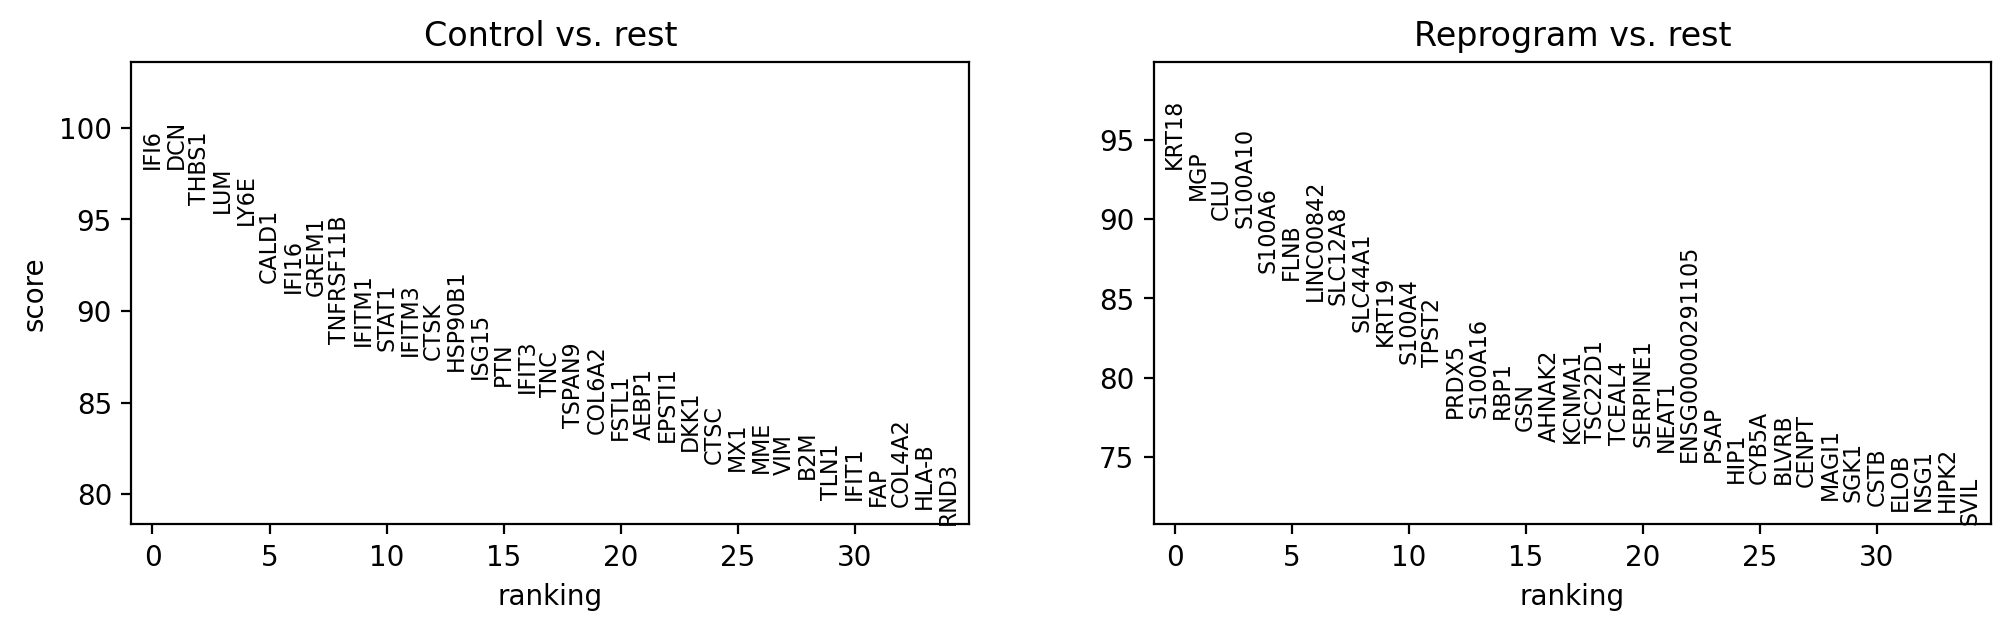

CPU times: user 23 s, sys: 11.8 s, total: 34.9 s
Wall time: 11.3 s


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,Control,IFI6,97.746857,5.784794,0.0,0.0,0.969524,0.432583
1,Control,DCN,97.741051,7.192836,0.0,0.0,0.952861,0.078667
2,Control,THBS1,95.819763,6.315111,0.0,0.0,0.949901,0.114701
3,Control,LUM,95.344391,6.772968,0.0,0.0,0.932800,0.051091
4,Control,LY6E,94.697006,2.988206,0.0,0.0,0.985201,0.692099


In [3]:
%%time
rsc.get.anndata_to_CPU(adata)
sc.tl.rank_genes_groups(
    adata, 
    groupby='group',
    method='wilcoxon',
    use_raw=False,
    pts=True,
)

deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 3
sc.pl.rank_genes_groups(
    adata,
    n_genes=35,
    sharey=False,
    ncols=3,
    
)

deg.head()

In [4]:
# Save to file

outpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/DEG/reprogram_v_control.csv"
deg.to_csv(outpath, index=False)
deg.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,Control,IFI6,97.746857,5.784794,0.0,0.0,0.969524,0.432583
1,Control,DCN,97.741051,7.192836,0.0,0.0,0.952861,0.078667
2,Control,THBS1,95.819763,6.315111,0.0,0.0,0.949901,0.114701
3,Control,LUM,95.344391,6.772968,0.0,0.0,0.932800,0.051091
4,Control,LY6E,94.697006,2.988206,0.0,0.0,0.985201,0.692099


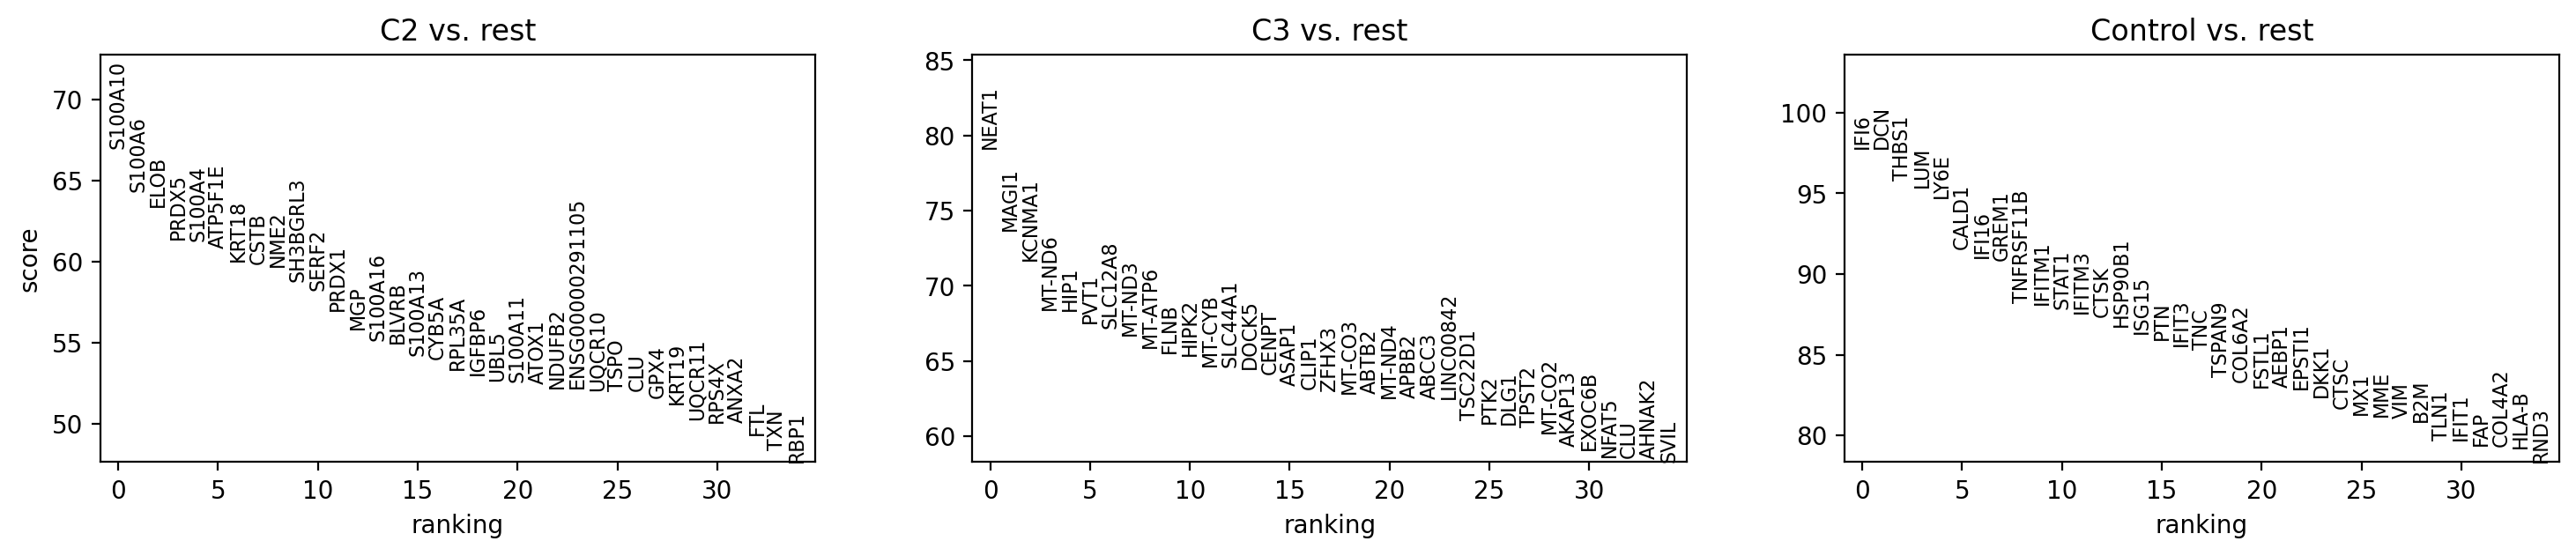

CPU times: user 23.5 s, sys: 12.2 s, total: 35.6 s
Wall time: 11.5 s


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,C2,S100A10,66.961838,2.258266,0.0,0.0,0.997709,0.964476
1,C2,S100A6,64.329781,1.457655,0.0,0.0,1.000000,0.997986
2,C2,ELOB,63.376724,1.167558,0.0,0.0,0.995800,0.979378
3,C2,PRDX5,61.376141,1.667238,0.0,0.0,0.982054,0.954245
4,C2,S100A4,61.274487,1.825569,0.0,0.0,0.997327,0.985742


In [5]:
%%time
rsc.get.anndata_to_CPU(adata)
sc.tl.rank_genes_groups(
    adata, 
    groupby='cell_type',
    method='wilcoxon',
    use_raw=False,
    pts=True,
)

deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 3
sc.pl.rank_genes_groups(
    adata,
    n_genes=35,
    sharey=False,
    ncols=3,
    
)

deg.head()

In [6]:
# Save to file

outpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/DEG/reprogram_clusters_v_control.csv"
deg.to_csv(outpath, index=False)
deg.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,C2,S100A10,66.961838,2.258266,0.0,0.0,0.997709,0.964476
1,C2,S100A6,64.329781,1.457655,0.0,0.0,1.000000,0.997986
2,C2,ELOB,63.376724,1.167558,0.0,0.0,0.995800,0.979378
3,C2,PRDX5,61.376141,1.667238,0.0,0.0,0.982054,0.954245
4,C2,S100A4,61.274487,1.825569,0.0,0.0,0.997327,0.985742
